# Chapter1 基于 Annoy 向量召回的推荐系统实战

在本节中，我们将使用 torch-rechub 框架训练一个 DSSM 双塔召回模型，
并结合 Annoy 向量检索库实现推荐系统中的召回环节。
通过本项目，你将理解向量数据库在推荐系统中的核心作用。

## 推荐系统召回概述

推荐系统通常采用多阶段漏斗架构：

![推荐系统漏斗架构](../../public/images/推荐系统漏斗图.png)

**召回（Recall）** 是推荐系统的第一个环节，目标是从海量物品中快速筛选出
用户可能感兴趣的候选集。召回的核心要求是：速度快、覆盖广。

向量召回的核心思想：
- 将用户和物品分别编码为向量（Embedding）
- 在同一向量空间中，通过近似最近邻（ANN）搜索找到与用户最相似的物品
- 相比规则召回（协同过滤、热门推荐），向量召回能捕捉更深层的语义关系

## 向量数据库在推荐召回中的角色

在推荐系统的向量召回中，向量数据库（或 ANN 检索库）扮演着关键角色：

1. **离线阶段**：训练双塔模型，生成所有物品的 Embedding，构建 ANN 索引
2. **在线阶段**：用户请求到来时，实时计算用户 Embedding，查询索引获取候选集

Annoy 是 Spotify 开源的轻量级 ANN 检索库，特别适合单机、中等规模的召回场景：
- 基于随机投影树（Random Projection Trees），查询速度快
- 支持内存映射（mmap），多进程可共享同一份索引文件
- API 简洁，易于集成

如果你还不熟悉 Annoy，建议先阅读本教程的：
- Annoy入门与环境搭建：/Annoy/chapter1/Annoy入门与环境搭建
- Annoy核心API详解：/Annoy/chapter2/Annoy核心API详解

## DSSM 双塔模型简介

DSSM（Deep Structured Semantic Model）是经典的双塔召回模型：

![双塔模型架构](/images/双塔模型.png)

- 用户塔（User Tower）：输入用户的稀疏特征（ID、性别、年龄等）和序列特征（观看历史），
  经过 Embedding + MLP 输出用户向量
- 物品塔（Item Tower）：输入物品的稀疏特征（ID、类别），经过 Embedding + MLP 输出物品向量
- 训练时通过正负样本对比学习，使得用户与其喜欢的物品在向量空间中距离更近
- 推理时分别获取用户/物品向量，用 ANN 检索完成召回

论文：https://www.microsoft.com/en-us/research/wp-content/uploads/2016/02/cikm2013_DSSM_fullversion.pdf

### 1. 环境准备

本项目依赖以下库：
- `torch-rechub`：推荐系统模型框架（包含 DSSM 模型和 Annoy 封装）
- `torch`：深度学习框架
- `pandas`、`numpy`、`scikit-learn`：数据处理
- `annoy`：近似最近邻检索

安装命令：
```bash
pip install torch-rechub annoy torch pandas numpy scikit-learn
```

> **Windows 用户注意**：annoy 需要 C++ 编译环境，如果 pip 安装失败，可使用 `conda install -c conda-forge python-annoy`。

In [33]:
import torch
import pandas as pd
import numpy as np
import os
import collections
import time
from sklearn.preprocessing import LabelEncoder

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)
_ = torch.manual_seed(2022)

### 2. 数据集介绍：MovieLens-1M

MovieLens-1M 是电影推荐领域的经典数据集，包含约 100 万条用户对电影的评分记录。

| 字段       | 含义       | 示例                                    |
|------------|------------|-----------------------------------------|
| user_id    | 用户ID     | 1                                       |
| movie_id   | 电影ID     | 1193                                    |
| rating     | 评分 (1-5) | 5                                       |
| timestamp  | 时间戳     | 978300760                               |
| title      | 电影名称   | One Flew Over the Cuckoo's Nest (1975)  |
| genres     | 电影类型   | Drama                                   |
| gender     | 用户性别   | F                                       |
| age        | 用户年龄段 | 1                                       |
| occupation | 用户职业   | 10                                      |
| zip        | 用户邮编   | 48067                                   |

本教程使用采样后的 `ml-1m_sample.csv`（100条样本，包含 2 个用户、93 部电影）进行调试。
跑通代码后，可下载全量数据集（约100万条）测试效果。
全量数据集下载：https://grouplens.org/datasets/movielens/1m/

In [34]:
file_path = 'ml-1m_sample.csv'
data = pd.read_csv(file_path)
print(f"数据集大小: {data.shape}")
print(f"用户数: {data['user_id'].nunique()}, 电影数: {data['movie_id'].nunique()}")
print(data.head())

数据集大小: (100, 10)
用户数: 2, 电影数: 93
   user_id  movie_id  rating  timestamp                                   title                        genres gender  age  occupation    zip
0        1      1193       5  978300760  One Flew Over the Cuckoo's Nest (1975)                         Drama      F    1          10  48067
1        1       661       3  978302109        James and the Giant Peach (1996)  Animation|Children's|Musical      F    1          10  48067
2        1       914       3  978301968                     My Fair Lady (1964)               Musical|Romance      F    1          10  48067
3        1      3408       4  978300275                  Erin Brockovich (2000)                         Drama      F    1          10  48067
4        1      2355       5  978824291                    Bug's Life, A (1998)   Animation|Children's|Comedy      F    1          10  48067


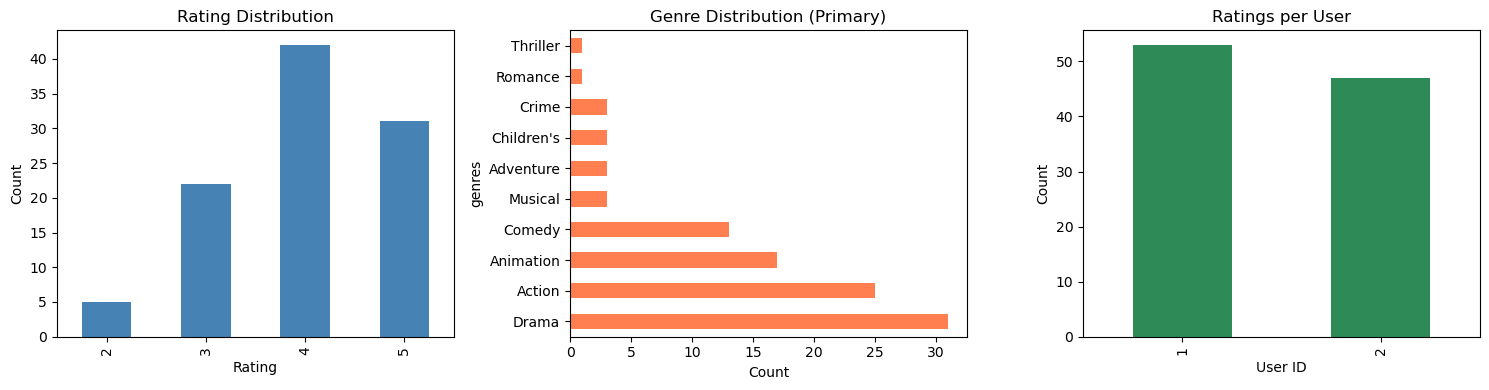

In [35]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Rating distribution
data['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Rating Distribution')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

# Genre distribution (first genre)
genre_counts = data['genres'].apply(lambda x: x.split('|')[0]).value_counts()
genre_counts.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Genre Distribution (Primary)')
axes[1].set_xlabel('Count')

# Ratings per user
user_counts = data['user_id'].value_counts().sort_index()
user_counts.plot(kind='bar', ax=axes[2], color='seagreen')
axes[2].set_title('Ratings per User')
axes[2].set_xlabel('User ID')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

### 3. 特征工程

在 DSSM 模型中，我们使用两类特征：

- **稀疏特征（SparseFeature）**：离散值（如用户ID、性别），
  经过 LabelEncoding 后输入 Embedding 层，输出一个 Embedding 向量。

- **序列特征（SequenceFeature）**：用户的历史行为序列（如观看历史），
  对序列中每个元素取 Embedding 后做平均池化，输出一个 Embedding 向量。

In [36]:
# 提取电影的第一个类型作为类别特征
data["cate_id"] = data["genres"].apply(lambda x: x.split("|")[0])

# 定义特征列
user_col, item_col = "user_id", "movie_id"
sparse_features = ['user_id', 'movie_id', 'gender', 'age', 'occupation', 'zip', "cate_id"]

# LabelEncoding：将离散特征转换为连续整数
feature_max_idx = {}
for feature in sparse_features:
    lbe = LabelEncoder()
    data[feature] = lbe.fit_transform(data[feature]) + 1
    feature_max_idx[feature] = data[feature].max() + 1
    if feature == user_col:
        user_map = {encode_id + 1: raw_id for encode_id, raw_id in enumerate(lbe.classes_)}
    if feature == item_col:
        item_map = {encode_id + 1: raw_id for encode_id, raw_id in enumerate(lbe.classes_)}

# 保存 ID 映射
save_dir = './saved/'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
np.save(save_dir + "raw_id_maps.npy", (user_map, item_map))

# 定义用户塔和物品塔的特征列
user_cols = ["user_id", "gender", "age", "occupation", "zip"]
item_cols = ['movie_id', "cate_id"]

user_profile = data[user_cols].drop_duplicates('user_id')
item_profile = data[item_cols].drop_duplicates('movie_id')

print(f"特征编码完成，共 {len(sparse_features)} 个稀疏特征")
print(f"用户特征: {user_cols}")
print(f"物品特征: {item_cols}")

特征编码完成，共 7 个稀疏特征
用户特征: ['user_id', 'gender', 'age', 'occupation', 'zip']
物品特征: ['movie_id', 'cate_id']


### 4. 生成序列特征

推荐系统中，用户的历史行为序列是非常重要的特征。
我们根据时间戳为每个用户生成观看历史序列。

关键参数说明：
- mode=0：Point-wise 训练方式（DSSM 使用此方式）
- neg_ratio=3：每个正样本对应3个负样本
- min_item=0：不过滤冷启动用户
- sample_method=1：负采样方法

In [37]:
from torch_rechub.utils.match import generate_seq_feature_match, gen_model_input

# 生成序列特征和训练/测试集
df_train, df_test = generate_seq_feature_match(
    data,
    user_col,
    item_col,
    time_col="timestamp",
    item_attribute_cols=[],
    sample_method=1,
    mode=0,           # point-wise
    neg_ratio=3,       # 每个正样本对应3个负样本
    min_item=0
)

print(f"训练集大小: {df_train.shape[0]}, 测试集大小: {df_test.shape[0]}")
print(df_train.head())

# 生成模型输入（将 DataFrame 转为模型需要的字典格式）
x_train = gen_model_input(df_train, user_profile, user_col, item_profile, item_col, seq_max_len=50)
y_train = x_train["label"]
x_test = gen_model_input(df_test, user_profile, user_col, item_profile, item_col, seq_max_len=50)

print("训练数据样例:")
print({k: v[:2] for k, v in x_train.items()})

# 定义特征类型
from torch_rechub.basic.features import SparseFeature, SequenceFeature

# 用户塔特征定义
user_features = [
    SparseFeature(feature_name, vocab_size=feature_max_idx[feature_name], embed_dim=16)
    for feature_name in user_cols
]
# 添加历史行为序列特征（与 movie_id 共享 Embedding 权重）
user_features += [
    SequenceFeature("hist_movie_id",
                    vocab_size=feature_max_idx["movie_id"],
                    embed_dim=16,
                    pooling="mean",
                    shared_with="movie_id")
]

# 物品塔特征定义
item_features = [
    SparseFeature(feature_name, vocab_size=feature_max_idx[feature_name], embed_dim=16)
    for feature_name in item_cols
]

print("用户塔特征:", user_features)
print("物品塔特征:", item_features)

# 准备 DataLoader
from torch_rechub.utils.data import df_to_dict, MatchDataGenerator

all_item = df_to_dict(item_profile)
test_user = x_test

dg = MatchDataGenerator(x=x_train, y=y_train)
train_dl, test_dl, item_dl = dg.generate_dataloader(test_user, all_item, batch_size=256)
print("DataLoader 生成完毕")

preprocess data


generate sequence features: 100%|██████████| 2/2 [00:00<00:00, 1374.06it/s]

n_train: 384, n_test: 2
0 cold start user dropped 
训练集大小: 384, 测试集大小: 2
   user_id  movie_id                                      hist_movie_id  histlen_movie_id  label
0        1        68  [87, 25, 41, 51, 65, 53, 91, 34, 74, 32, 5, 18...                48      0
1        1         8                                               [87]                 1      0
2        2        63  [37, 35, 43, 32, 78, 36, 34, 92, 3, 79, 86, 82...                24      0
3        2        63                       [37, 35, 43, 32, 78, 36, 34]                 7      0
4        1        75  [87, 25, 41, 51, 65, 53, 91, 34, 74, 32, 5, 18...                26      0
训练数据样例:
{'user_id': array([1, 1]), 'movie_id': array([68,  8]), 'hist_movie_id': array([[ 0,  0, 87, 25, 41, 51, 65, 53, 91, 34, 74, 32,  5, 18, 23, 14,
        70, 55, 58, 82, 24, 28, 56, 26, 57,  4, 29, 22, 42, 73, 71, 38,
        17, 77, 10, 85, 72, 64, 27, 12, 33, 67, 47,  9, 19, 69, 13, 11,
         1, 63],
       [ 0,  0,  0,  0,  0,  0, 

### 5. DSSM 模型训练

关键超参数：
- temperature=0.02：温度系数，控制 softmax 的平滑程度
- dims=[256, 128, 64]：MLP 各层维度，最终输出 64 维 Embedding
- activation='prelu'：激活函数（对效果影响较大，建议不要修改）
- in_batch_neg=True：使用 batch 内负采样，提升训练效率

In [38]:
from torch_rechub.models.matching import DSSM
from torch_rechub.trainers import MatchTrainer

# 定义 DSSM 双塔模型
model = DSSM(
    user_features,
    item_features,
    temperature=0.02,
    user_params={
        "dims": [256, 128, 64],
        "activation": 'prelu',
    },
    item_params={
        "dims": [256, 128, 64],
        "activation": 'prelu',
    }
)

# 定义训练器
trainer = MatchTrainer(
    model,
    mode=0,                          # point-wise
    in_batch_neg=True,               # batch 内负采样
    in_batch_neg_ratio=3,            # 负采样比例
    optimizer_params={
        "lr": 1e-4,
        "weight_decay": 1e-6
    },
    n_epoch=5,                       # 训练轮数（sample 数据可设为 1-5）
    device='cpu',                    # 无 GPU 时使用 cpu
    model_path=save_dir
)

# 开始训练
print("开始训练 DSSM 模型...")
trainer.fit(train_dl)
print("训练完成！")

开始训练 DSSM 模型...
epoch: 0


train: 100%|██████████| 2/2 [00:43<00:00, 21.98s/it]


epoch: 1


train: 100%|██████████| 2/2 [00:42<00:00, 21.01s/it]


epoch: 2


...

epoch: 3


train: 100%|██████████| 2/2 [00:40<00:00, 20.45s/it]


epoch: 4


train: 100%|██████████| 2/2 [00:41<00:00, 20.52s/it]

训练完成！


### 6. 基于 Annoy 的向量召回

训练完成后，我们使用模型分别推理出用户 Embedding 和物品 Embedding，
然后用 Annoy 构建物品向量索引，实现高效的近似最近邻召回。

核心流程：
1. 通过模型的 User Tower 获取所有测试用户的 Embedding
2. 通过模型的 Item Tower 获取所有物品的 Embedding
3. 用 Annoy 对物品 Embedding 建立索引（n_trees=10）
4. 对每个用户 Embedding 查询 Top-K 最近邻物品

这里使用的 torch_rechub.utils.match.Annoy 是对原生 annoy 库的封装，
底层调用的就是 Annoy教程 中学到的 AnnoyIndex。

In [39]:
print("正在推理用户 Embedding...")
user_embedding = trainer.inference_embedding(
    model=model, mode="user", data_loader=test_dl, model_path=save_dir
)
print(f"用户 Embedding 维度: {user_embedding.shape}")

print("正在推理物品 Embedding...")
item_embedding = trainer.inference_embedding(
    model=model, mode="item", data_loader=item_dl, model_path=save_dir
)
print(f"物品 Embedding 维度: {item_embedding.shape}")

# 使用 Annoy 构建索引并召回
from torch_rechub.utils.match import Annoy

print("正在构建 Annoy 索引...")
annoy = Annoy(n_trees=10)
annoy.fit(item_embedding)
print(f"Annoy 索引构建完成，共索引 {item_embedding.shape[0]} 个物品向量")

# 对测试用户进行 Top-K 召回
topk = 10
user_map, item_map = np.load(save_dir + "raw_id_maps.npy", allow_pickle=True)
match_res = collections.defaultdict(dict)

for user_id, user_emb in zip(test_user[user_col], user_embedding):
    items_idx, items_scores = annoy.query(v=user_emb, n=topk)
    match_res[user_map[user_id]] = np.vectorize(item_map.get)(all_item[item_col][items_idx])

print("\n召回结果示例（用户 -> 推荐电影列表）:")
for uid, movies in match_res.items():
    print(f"  用户 {uid}: {movies}")

正在推理用户 Embedding...


user inference: 100%|██████████| 1/1 [00:07<00:00,  7.46s/it]


用户 Embedding 维度: torch.Size([2, 64])
正在推理物品 Embedding...


item inference: 100%|██████████| 1/1 [00:07<00:00,  7.46s/it]

物品 Embedding 维度: torch.Size([93, 64])
正在构建 Annoy 索引...
Annoy 索引构建完成，共索引 93 个物品向量

召回结果示例（用户 -> 推荐电影列表）:
  用户 1: [2340 3186 1270  661 2804  531 1566 1962 1721 1217]
  用户 2: [2340 3186 1270  661 2804  531 1566 1721 1962 1217]


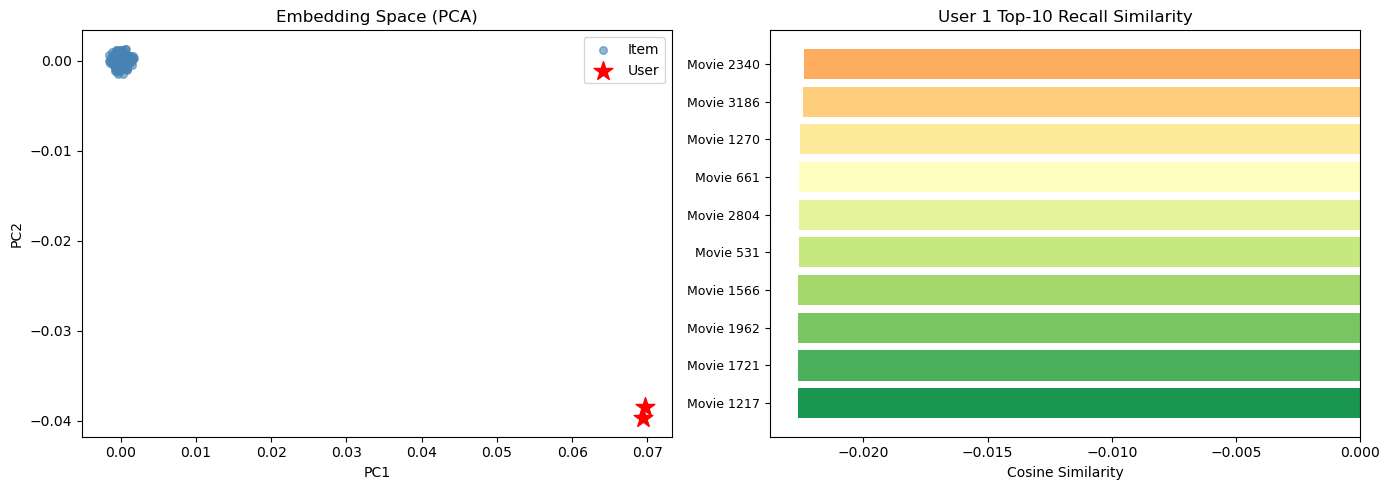

PCA explained variance ratio: [0.33942494 0.21680334]


In [40]:
from sklearn.decomposition import PCA

# Embedding to numpy
item_emb_np = item_embedding.numpy() if hasattr(item_embedding, 'numpy') else np.array(item_embedding)
user_emb_np = user_embedding.numpy() if hasattr(user_embedding, 'numpy') else np.array(user_embedding)

# PCA to 2D
pca = PCA(n_components=2)
item_2d = pca.fit_transform(item_emb_np)
user_2d = pca.transform(user_emb_np)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Embedding space (PCA)
axes[0].scatter(item_2d[:, 0], item_2d[:, 1], c='steelblue', alpha=0.6, s=30, label='Item')
axes[0].scatter(user_2d[:, 0], user_2d[:, 1], c='red', marker='*', s=200, zorder=5, label='User')
axes[0].set_title('Embedding Space (PCA)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()

# Right: Cosine similarity of Top-K recalled items
from numpy.linalg import norm
uid_example = list(match_res.keys())[0]
user_emb_example = user_emb_np[0]
similarities = []
labels = []
for movie_id in match_res[uid_example]:
    idx = np.where(all_item[item_col] == item_map.get(movie_id, movie_id))[0]
    if len(idx) == 0:
        inv_item_map = {v: k for k, v in item_map.items()}
        idx = np.where(all_item[item_col] == inv_item_map.get(movie_id, -1))[0]
    if len(idx) > 0:
        cos_sim = np.dot(user_emb_example, item_emb_np[idx[0]]) / (norm(user_emb_example) * norm(item_emb_np[idx[0]]) + 1e-8)
        similarities.append(cos_sim)
        labels.append(str(movie_id))

if similarities:
    colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(similarities)))
    axes[1].barh(range(len(similarities)), similarities, color=colors)
    axes[1].set_yticks(range(len(labels)))
    axes[1].set_yticklabels([f'Movie {l}' for l in labels], fontsize=9)
    axes[1].set_xlabel('Cosine Similarity')
    axes[1].set_title(f'User {uid_example} Top-{topk} Recall Similarity')
    axes[1].invert_yaxis()

plt.tight_layout()
plt.show()
print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")

### 7. 召回效果评估

常见的 Top-K 评估指标：

| 指标         | 含义                                                       |
|--------------|------------------------------------------------------------|
| Recall@K     | 在 Top-K 召回结果中，命中的正样本占所有正样本的比例        |
| Precision@K  | 在 Top-K 召回结果中，命中的正样本占 K 的比例               |
| Hit@K        | 至少命中一个正样本的用户比例                               |
| NDCG@K       | 归一化折损累积增益，考虑了命中位置的排序质量               |
| MRR@K        | 平均倒数排名，关注第一个命中结果的位置                     |

> **注意**：使用 sample 数据集（仅 2 个用户、93 部电影）时，所有指标均为 0.0 是正常现象——样本量太小，模型无法充分学习用户偏好。使用全量数据集（100万条）训练后效果会显著提升。

In [41]:
from torch_rechub.basic.metric import topk_metrics

# 构建 ground truth（测试集中用户实际交互的物品）
data_test = pd.DataFrame({user_col: test_user[user_col], item_col: test_user[item_col]})
data_test[user_col] = data_test[user_col].map(user_map)
data_test[item_col] = data_test[item_col].map(item_map)
user_pos_item = data_test.groupby(user_col).agg(list).reset_index()
ground_truth = dict(zip(user_pos_item[user_col], user_pos_item[item_col]))

# 计算 Top-K 指标
print("召回效果评估:")
out = topk_metrics(y_true=ground_truth, y_pred=match_res, topKs=[topk])
print(out)

召回效果评估:
defaultdict(<class 'list'>, {'NDCG': ['NDCG@10: 0.0'], 'MRR': ['MRR@10: 0.0'], 'Recall': ['Recall@10: 0.0'], 'Hit': ['Hit@10: 0.0'], 'Precision': ['Precision@10: 0.0']})


### 8. 深入理解：Annoy 在推荐召回中的作用

`torch_rechub.utils.match.Annoy` 封装的核心逻辑等价于以下原生 annoy 代码：

```python
from annoy import AnnoyIndex

dim = item_embedding.shape[1]  # 64
index = AnnoyIndex(dim, 'angular')  # angular 距离 ≈ cosine 距离

for i, emb in enumerate(item_embedding):
    index.add_item(i, emb)

index.build(n_trees=10)
ids, distances = index.get_nns_by_vector(user_emb, 10, include_distances=True)
```

下面我们手动使用原生 Annoy 来演示完整流程。

### 9. 参数调优：n_trees 对召回效果的影响

Annoy 的 `n_trees` 参数控制索引中树的数量：
- 树越多 → 召回越精确，但构建时间和内存占用越大
- 树越少 → 速度越快，但可能遗漏一些近邻

下面对比不同 `n_trees` 值的构建耗时和查询耗时。

更多调优建议请参考：/Annoy/chapter3/Annoy进阶技巧与最佳实践

n_trees=  1 | build: 0.0020s | query: 0.0000s | Recall@10: 0.0
n_trees=  5 | build: 0.0049s | query: 0.0000s | Recall@10: 0.0
n_trees= 10 | build: 0.0033s | query: 0.0000s | Recall@10: 0.0
n_trees= 50 | build: 0.0023s | query: 0.0000s | Recall@10: 0.0
n_trees=100 | build: 0.0025s | query: 0.0000s | Recall@10: 0.0


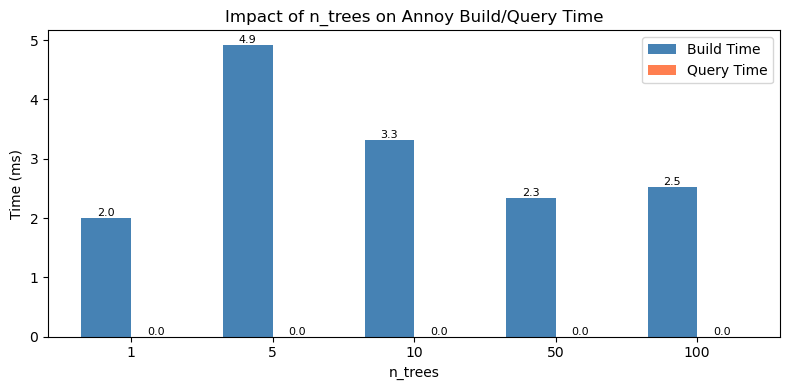

In [42]:
n_trees_list = [1, 5, 10, 50, 100]
build_times = []
query_times = []

for n_trees in n_trees_list:
    t0 = time.time()
    annoy_exp = Annoy(n_trees=n_trees)
    annoy_exp.fit(item_embedding)
    build_times.append(time.time() - t0)

    t0 = time.time()
    match_res_exp = collections.defaultdict(dict)
    for user_id, user_emb in zip(test_user[user_col], user_embedding):
        items_idx, items_scores = annoy_exp.query(v=user_emb, n=topk)
        match_res_exp[user_map[user_id]] = np.vectorize(item_map.get)(all_item[item_col][items_idx])
    query_times.append(time.time() - t0)

    out = topk_metrics(y_true=ground_truth, y_pred=match_res_exp, topKs=[topk])
    print(f"n_trees={n_trees:>3d} | build: {build_times[-1]:.4f}s | query: {query_times[-1]:.4f}s | {out['Recall'][0]}")

# Visualize n_trees impact
fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(n_trees_list))
width = 0.35
bars1 = ax.bar([i - width/2 for i in x], [t * 1000 for t in build_times], width, label='Build Time', color='steelblue')
bars2 = ax.bar([i + width/2 for i in x], [t * 1000 for t in query_times], width, label='Query Time', color='coral')
ax.set_xlabel('n_trees')
ax.set_ylabel('Time (ms)')
ax.set_title('Impact of n_trees on Annoy Build/Query Time')
ax.set_xticks(x)
ax.set_xticklabels(n_trees_list)
ax.legend()
ax.bar_label(bars1, fmt='%.1f', fontsize=8)
ax.bar_label(bars2, fmt='%.1f', fontsize=8)
plt.tight_layout()
plt.show()

## 讨论：向量数据库如何赋能推荐系统

1. **离线训练 + 在线召回的架构**
   - 离线阶段：训练 DSSM 模型，生成所有物品的 Embedding，构建 Annoy 索引
   - 在线阶段：用户请求到来时，实时计算用户 Embedding，查询 Annoy 索引获取候选集
   - Annoy 的内存映射特性使得多个服务进程可以共享同一份索引文件，非常适合 Web 服务部署

2. **Annoy vs 其他向量检索方案**

   | 方案   | 适用场景               | 优势                           | 局限               |
   |--------|------------------------|--------------------------------|--------------------|
   | Annoy  | 单机、中等规模、只读   | 内存映射、多进程共享、API 简洁 | 不支持增量更新     |
   | FAISS  | 单机、大规模、需要 GPU | 索引类型丰富、GPU 加速         | 部署复杂度较高     |
   | Milvus | 分布式、超大规模       | 分布式扩展、实时增删改         | 需要部署服务       |

3. **从召回到完整推荐系统**
   - 本项目实现的是推荐系统的"召回"环节
   - 完整的推荐系统还需要：粗排（简单模型快速打分）→ 精排（复杂模型精细打分）→ 重排（业务规则调整）
   - 向量数据库在召回层的价值：将 O(N) 的暴力搜索降低到 O(log N) 的近似搜索

## 动手练习

### 任务1：运行并理解代码
- 逐步执行上面的代码，观察每一步的输出
- 思考：用户 Embedding 和物品 Embedding 的维度为什么是 64？这个维度由什么决定？

### 任务2：使用全量数据集
- 下载 MovieLens-1M 全量数据集（约100万条记录）
- 替换 file_path 为全量数据路径，重新训练模型
- 对比 sample 数据和全量数据的召回指标差异

### 任务3：调整 Annoy 参数
- 尝试不同的 n_trees 值（1, 10, 50, 100），观察对召回精度和速度的影响
- 尝试不同的距离度量（angular, euclidean, dot），对比效果
- 参考 Annoy进阶技巧与最佳实践 中的调优建议

### 任务4（进阶）：保存和加载 Annoy 索引
- 将训练好的 Annoy 索引保存到文件
- 编写一个独立的"在线召回服务"脚本：加载索引文件，接收用户特征，返回推荐结果
- 思考：在生产环境中，如何实现索引的定期更新？

**思考题：**
- Annoy 不支持增量更新，在推荐系统中如何处理新物品的加入？
- 如果物品数量达到千万级，Annoy 还适用吗？应该选择什么方案？
- 双塔模型的 Embedding 维度对召回效果和检索速度有什么影响？

## 参考资料

1. DSSM 论文：https://www.microsoft.com/en-us/research/wp-content/uploads/2016/02/cikm2013_DSSM_fullversion.pdf
2. torch-rechub 框架：https://github.com/datawhalechina/torch-rechub
3. Annoy GitHub：https://github.com/spotify/annoy
4. MovieLens 数据集：https://grouplens.org/datasets/movielens/1m/
5. Annoy入门与环境搭建：/Annoy/chapter1/Annoy入门与环境搭建
6. Annoy核心API详解：/Annoy/chapter2/Annoy核心API详解
7. Annoy进阶技巧与最佳实践：/Annoy/chapter3/Annoy进阶技巧与最佳实践